In [1]:
from pathlib import Path
import pandas as pd

data_folder = Path("Data/")
data_file = data_folder / "all_locations_train_data.csv/"

data_df = pd.read_csv(data_file)
print(data_df["location"].unique())

['kenya_location3' 'kenya_location4' 'ghana_location1' 'kenya_location2'
 'ghana_location2' 'soroti' 'wadelai' 'nigeria_location1'
 'kenya_location5' 'kenya_location7' 'kenya_location6' 'ghana_location3'
 'kenya_location8' 'nigeria_location2' 'madagascar_location1'
 'egypt_location1' 'madagascar_location2' 'kenya_location13'
 'kenya_location14' 'kenya_location10' 'somalia_location1'
 'kenya_location12' 'kenya_location9' 'kenya_location11'
 'nigeria_location3']


In [2]:
data_df.head()

,datetime,ghi,location,T2M,ALLSKY_SFC_SW_DWN,RH2M,WS2M,T2MDEW,T2M_MAX,T2M_MIN,...,ghi_clear_cams,bhi_clear_cams,dhi_clear_cams,dni_clear_cams,ghi_cams,bhi_cams,dhi_cams,dni_cams,latitude,longitude
0,2019-05-28,4.5895,kenya_location3,20.24,5.85,75.35,1.89,15.40,25.60,15.51,...,7028.7080,5860.6655,1168.0425,8644.8447,5709.2358,3214.8335,2494.4021,5085.8491,-0.469974,35.181874
1,2019-05-29,6.4772,kenya_location3,19.79,5.87,79.56,1.69,15.93,24.54,16.12,...,6983.8623,5600.8086,1383.0536,8156.0479,5820.1196,3751.4502,2068.6694,5344.3003,-0.469974,35.181874
2,2019-05-30,4.0908,kenya_location3,20.29,5.81,77.34,2.23,15.90,25.47,15.59,...,7108.9385,6082.7812,1026.1572,9049.8369,4649.3599,2996.5430,1652.8168,4057.3140,-0.469974,35.181874
3,2019-05-31,5.9658,kenya_location3,20.34,5.61,79.87,1.31,16.53,24.50,17.26,...,6939.8794,5645.0093,1294.8701,8293.1592,5853.1040,4095.9358,1757.1682,5564.8662,-0.469974,35.181874
4,2019-06-01,3.7295,kenya_location3,18.56,4.12,87.30,1.57,16.37,21.07,16.83,...,6752.1333,5060.3564,1691.7769,7281.5659,3706.7803,1383.7960,2322.9841,1843.5648,-0.469974,35.181874


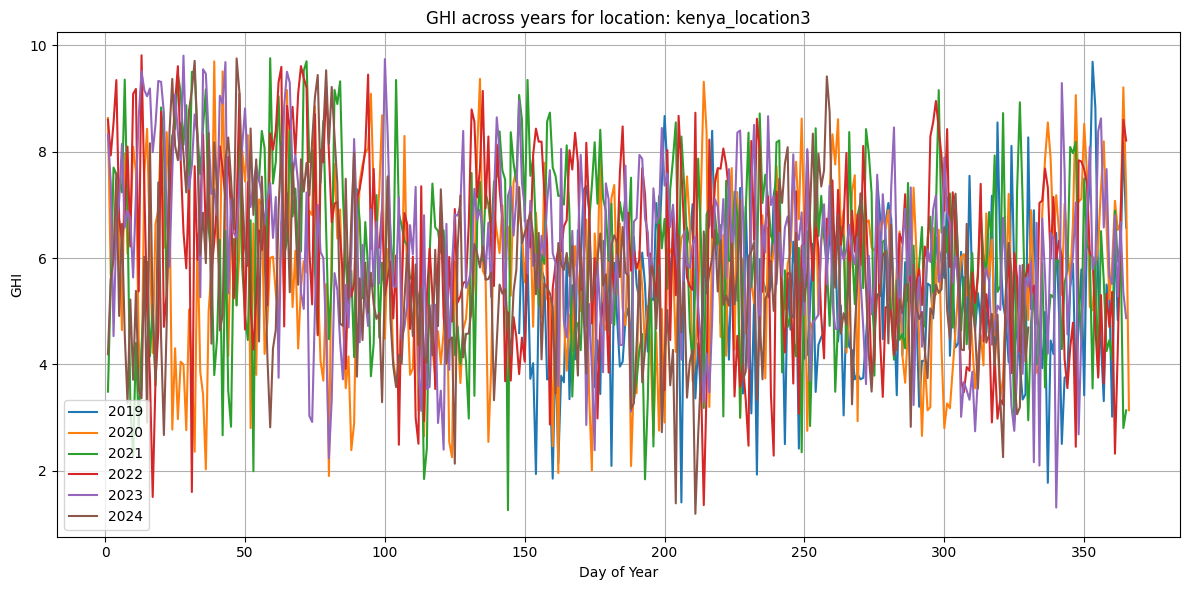

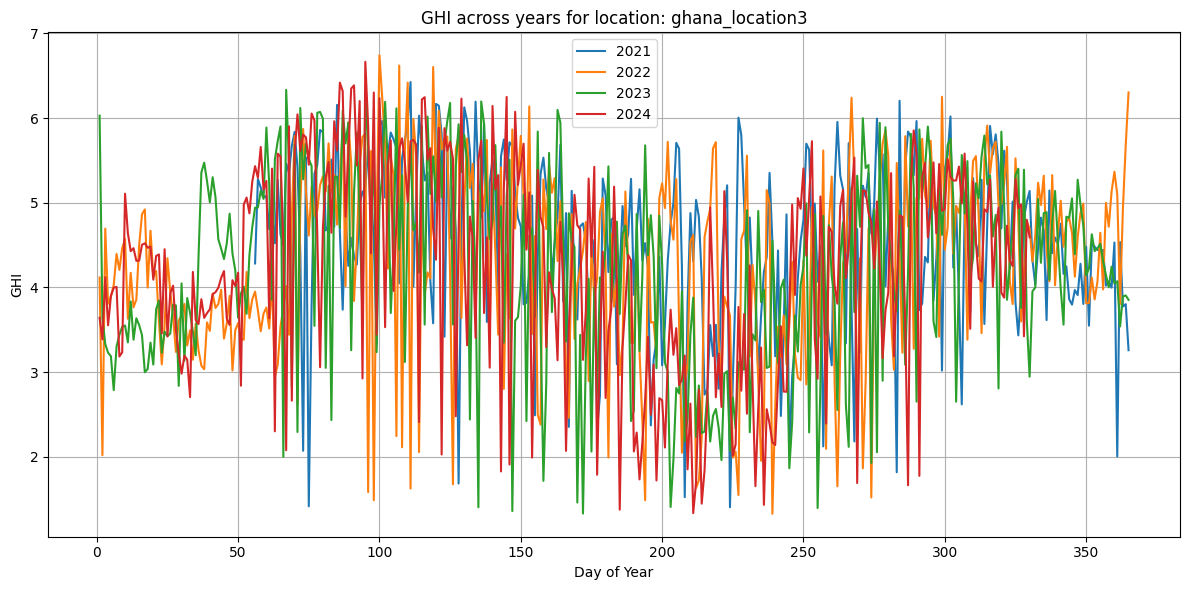

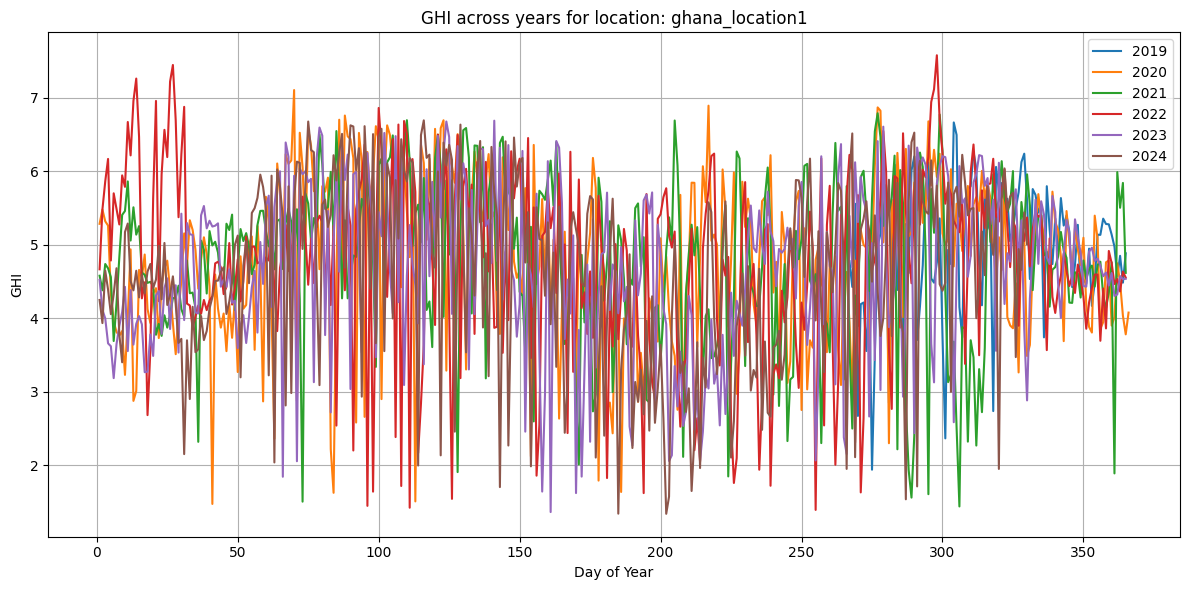

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert 'datetime' column to datetime object
data_df['datetime'] = pd.to_datetime(data_df['datetime'])
data_df['year'] = data_df['datetime'].dt.year
data_df['DoY'] = data_df['datetime'].dt.dayofyear

# Select 3 example locations
example_locations = ['kenya_location3', 'ghana_location3', 'ghana_location1']

for loc in example_locations:
    loc_df = data_df[data_df['location'] == loc]

    plt.figure(figsize=(12, 6))
    for year in sorted(loc_df['year'].unique()):
        yearly_data = loc_df[loc_df['year'] == year]
        plt.plot(yearly_data['DoY'], yearly_data['ghi'], label=str(year))

    plt.title(f'GHI across years for location: {loc}')
    plt.xlabel('Day of Year')
    plt.ylabel('GHI')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split

# Get unique locations and split them
unique_locations = data_df['location'].unique()
train_locs, val_locs = train_test_split(unique_locations, test_size=0.2, random_state=42)

# Mark which set each row belongs to
data_df['set'] = data_df['location'].apply(lambda loc: 'train' if loc in train_locs else 'validation')

# Drop non-feature columns
features_to_exclude = ['datetime', 'location', 'ghi', 'year', 'latitude', 'set', 'error', 'sq_error']
X = data_df.drop(columns=features_to_exclude)
y = data_df['ghi']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a simple Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.3f}')


Mean Squared Error: 0.415


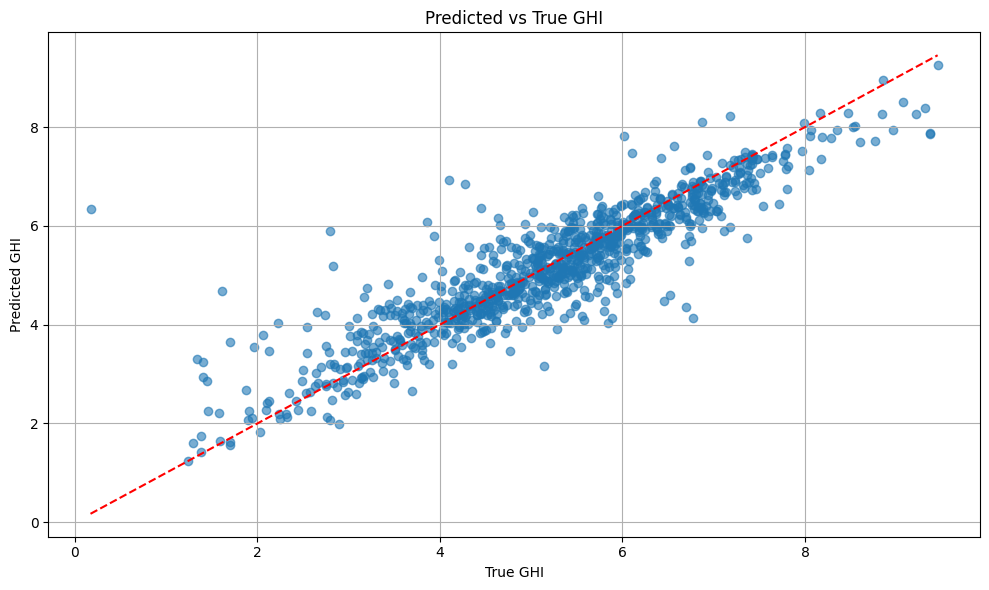

In [5]:
import numpy as np

# Sample a few predictions for plotting
sample_indices = np.random.choice(len(y_test), size=1000, replace=False)
sample_true = y_test.iloc[sample_indices].values
sample_pred = y_pred[sample_indices]

plt.figure(figsize=(10, 6))
plt.scatter(sample_true, sample_pred, alpha=0.6)
plt.plot([min(sample_true), max(sample_true)], [min(sample_true), max(sample_true)], 'r--')
plt.xlabel('True GHI')
plt.ylabel('Predicted GHI')
plt.title('Predicted vs True GHI')
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:

data_df['ghi_pred'] = model.predict(X)

In [11]:
def plot_ghi_comparison(data_df, location_name):
    """
    Plot true vs predicted GHI for all available years at a given location.
    """
    # Filter for the selected location
    loc_df = data_df[data_df['location'] == location_name].copy()

    # Ensure datetime and day-of-year columns exist
    if 'datetime' not in loc_df.columns or 'DoY' not in loc_df.columns:
        loc_df['datetime'] = pd.to_datetime(loc_df['datetime'])
        loc_df['DoY'] = loc_df['datetime'].dt.dayofyear
        loc_df['year'] = loc_df['datetime'].dt.year

    # Plot for each year
    for year in sorted(loc_df['year'].unique()):
        year_df = loc_df[loc_df['year'] == year]

        plt.figure(figsize=(12, 5))
        plt.plot(year_df['DoY'], year_df['ghi'], label='True GHI', color='red', linewidth=4)
        plt.plot(year_df['DoY'], year_df['ghi_pred'], label='Predicted GHI', color='orange', linestyle='--')
        plt.plot(year_df['DoY'], year_df['ALLSKY_SFC_SW_DWN'], label='NASA GHI', color='green', linestyle='--')
        plt.title(f"{location_name} - Year {year}")
        plt.xlabel("Day of Year")
        plt.ylabel("GHI")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


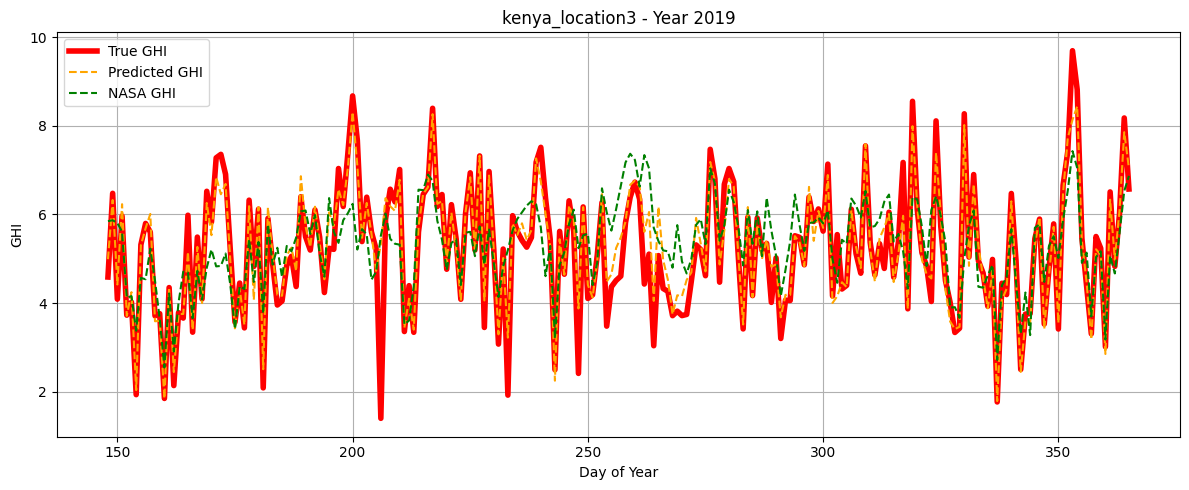

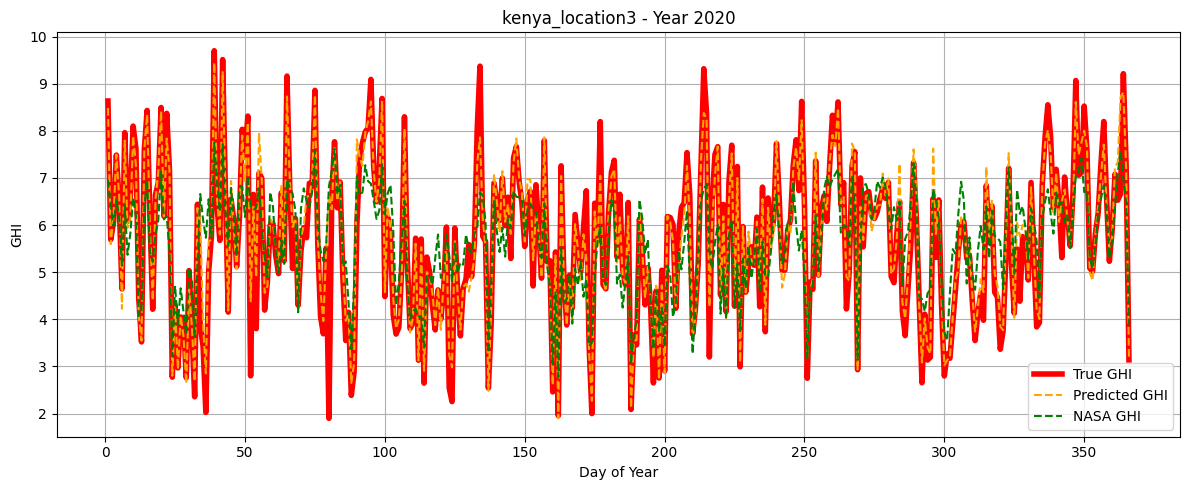

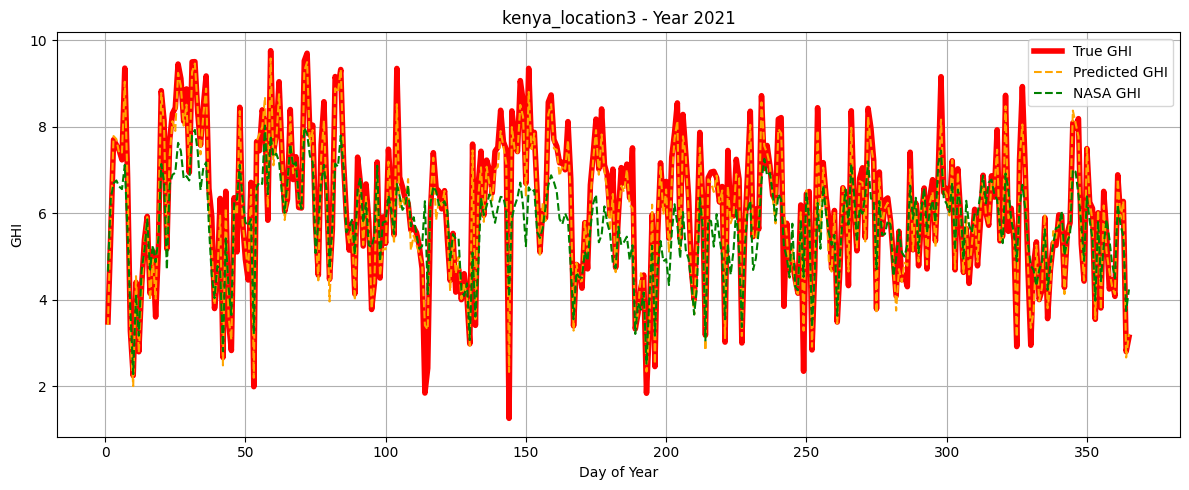

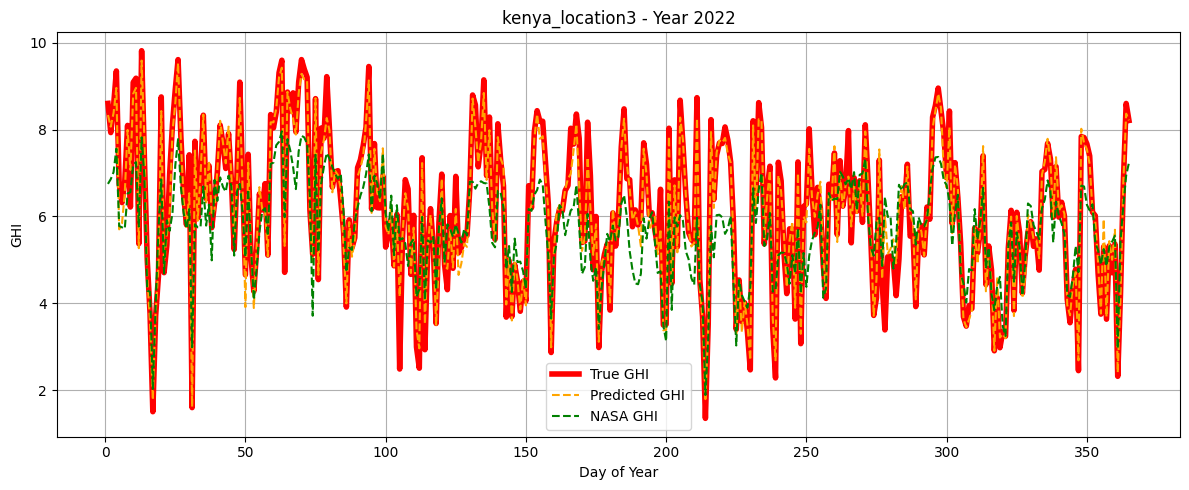

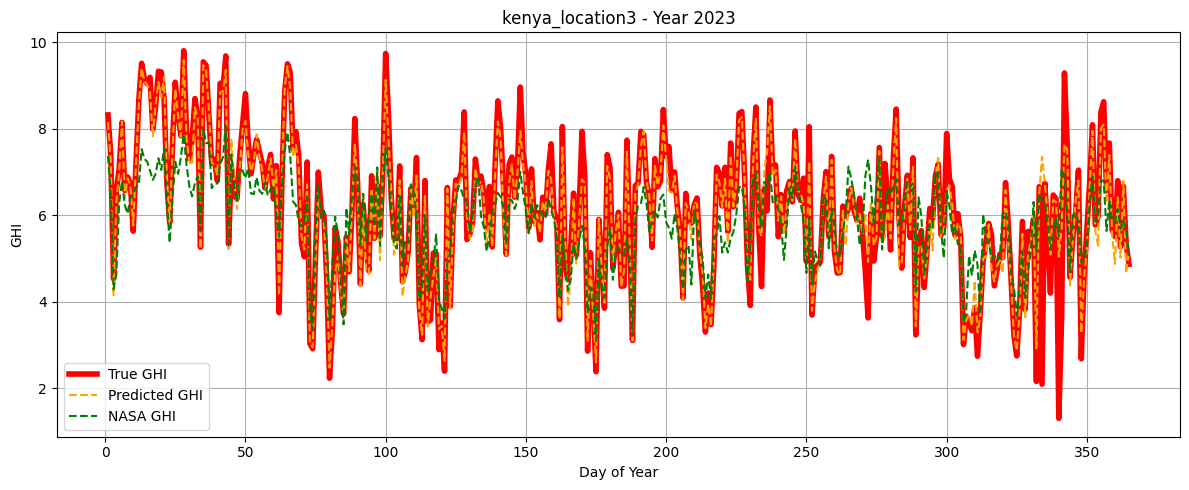

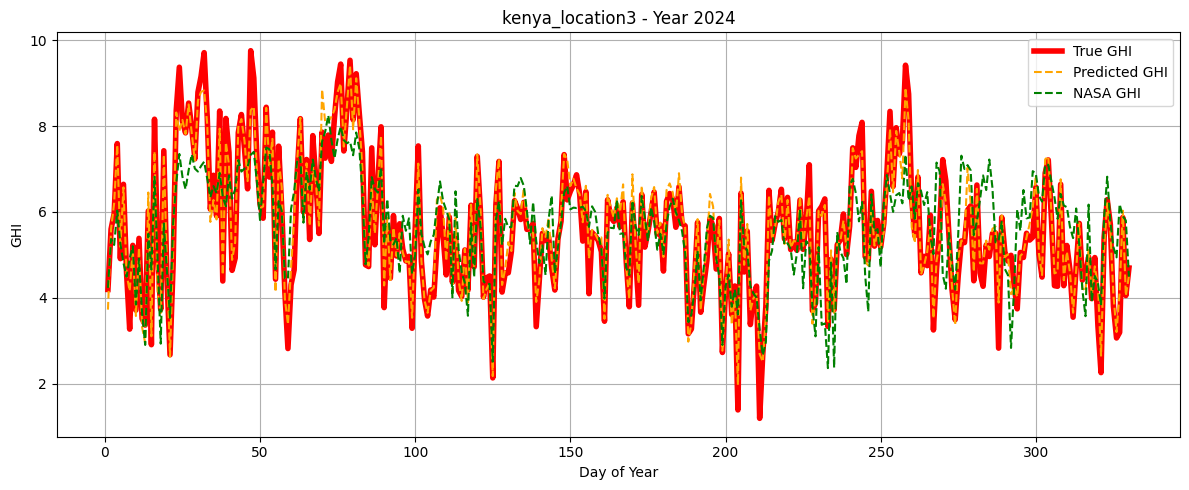

In [12]:
plot_ghi_comparison(data_df, location_name='kenya_location3')

In [13]:
import pandas as pd

# Combine X_train and y_train for correlation analysis
correlation_df = X_train.copy()
correlation_df['ghi'] = y_train

# Compute correlations
corr_matrix = correlation_df.corr(numeric_only=True)
ghi_corr = corr_matrix['ghi'].drop('ghi').sort_values(ascending=False)

# Print top correlated features
print("Top correlated features with target 'ghi':")
print(ghi_corr.head(10))


Top correlated features with target 'ghi':
ghi_cams               0.768760
ALLSKY_SFC_SW_DWN      0.748249
bhi_cams               0.740555
dni_cams               0.710140
ALLSKY_SFC_PAR_DIRH    0.575812
ALLSKY_SFC_SW_DNI      0.552601
ALLSKY_SFC_SW_DIRH     0.552585
PSH                    0.433959
ALLSKY_SFC_UV_INDEX    0.423864
ALLSKY_SFC_UVA         0.422392
Name: ghi, dtype: float64


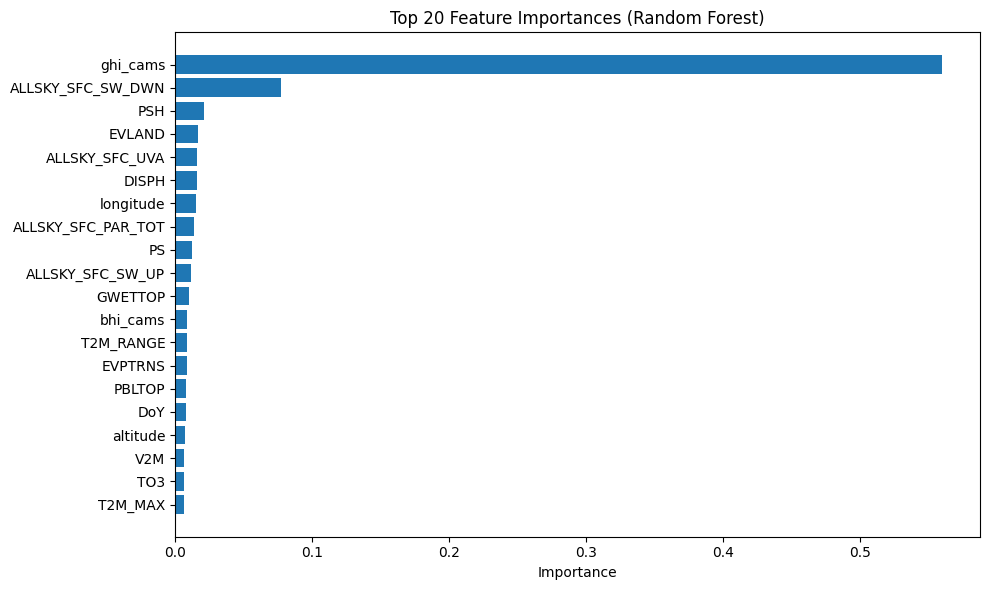

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the trained model
importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot top 20
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][:20][::-1], importance_df['importance'][:20][::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()
